In [2]:
import numpy as np
import pandas as pd
import xarray as xr
import rioxarray as rxr
from rioxarray.merge import merge_arrays
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker

# Hansen Forest Data

In [18]:
path='/projekt1/ag_maahn/data_obs_nobackup/amazonas/forest_loss/'

kacheln1 = [
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_050W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_060W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_070W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_00N_080W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_050W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_060W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_070W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10N_080W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_050W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_060W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_070W.tif"),
    rxr.open_rasterio(path+"Hansen_GFC-2024-v1.12_lossyear_10S_080W.tif")
]
mrd1 = merge_arrays(kacheln1)

In [19]:
path2='/projekt1/ag_maahn/data_obs_nobackup/amazonas/cover2000/'

kacheln2 = [
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_050W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_060W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_070W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_00N_080W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_050W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_060W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_070W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10N_080W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_050W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_060W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_070W.tif"),
    rxr.open_rasterio(path2+"Hansen_GFC-2024-v1.12_treecover2000_10S_080W.tif")
]

mrd2 =merge_arrays(kacheln2)

In [20]:
loss = mrd1.to_dataset(name="lossyear")
cvr = mrd2.to_dataset(name="cover2000")
ds=xr.merge([loss, cvr])
ds

/tmp/ipykernel_318577/1432654727.py:3: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds=xr.merge([loss, cvr])


<xarray.Dataset> Size: 38GB
Dimensions:      (x: 160000, y: 120000, band: 1)
Coordinates:
  * x            (x) float64 1MB -80.0 -80.0 -80.0 -80.0 ... -40.0 -40.0 -40.0
  * y            (y) float64 960kB 10.0 10.0 9.999 9.999 ... -20.0 -20.0 -20.0
  * band         (band) int64 8B 1
    spatial_ref  int64 8B 0
Data variables:
    lossyear     (band, y, x) uint8 19GB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    cover2000    (band, y, x) uint8 19GB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0

In [21]:
th=50 # % Threshold for beeing marked as forest, following the definition in the dataset for forest loss

maxX = round(float(ds['x'].max()),0)
minX = round(float(ds['x'].min()),0)

maxY = round(float(ds['y'].max()),0)
minY = round(float(ds['y'].min()),0)
 
#x_range = np.arange(minX, maxX+1)
#y_range = np.arange(minY, maxY+1)
#print(x_range)
#print(y_range)

In [116]:
# 1. create bolean arrays
cond_forest  = ds['cover2000'] >= th
cond_no_loss = ds['lossyear'] <= 1

# 2. Group in 1x1° bins and sum
forest_count      = cond_forest.groupby_bins('x', np.arange(minX, maxX+1)) \
                               .sum() \
                               .groupby_bins('y', np.arange(minY, maxY+1)) \
                               .sum()

still_forest_count = (cond_forest & cond_no_loss) \
                               .groupby_bins('x', np.arange(minX, maxX+1)) \
                               .sum() \
                               .groupby_bins('y', np.arange(minY, maxY+1)) \
                               .sum()

# 3. Degree of Deforestation
DoD = (forest_count - still_forest_count) / forest_count.where(forest_count > 0)

#Difference (pixel count) of forest area in 2001 and 2024

Fo_diff=forest_count.where(forest_count > 0) - still_forest_count

In [117]:
ds_dod = DoD.to_dataset(name="DoD")
ds_Fo_diff= Fo_diff.to_dataset(name="Difference")

In [118]:
# set boundary values for map-plots
lon_min, lon_max = -85, -35
lat_min, lat_max = -35, 15

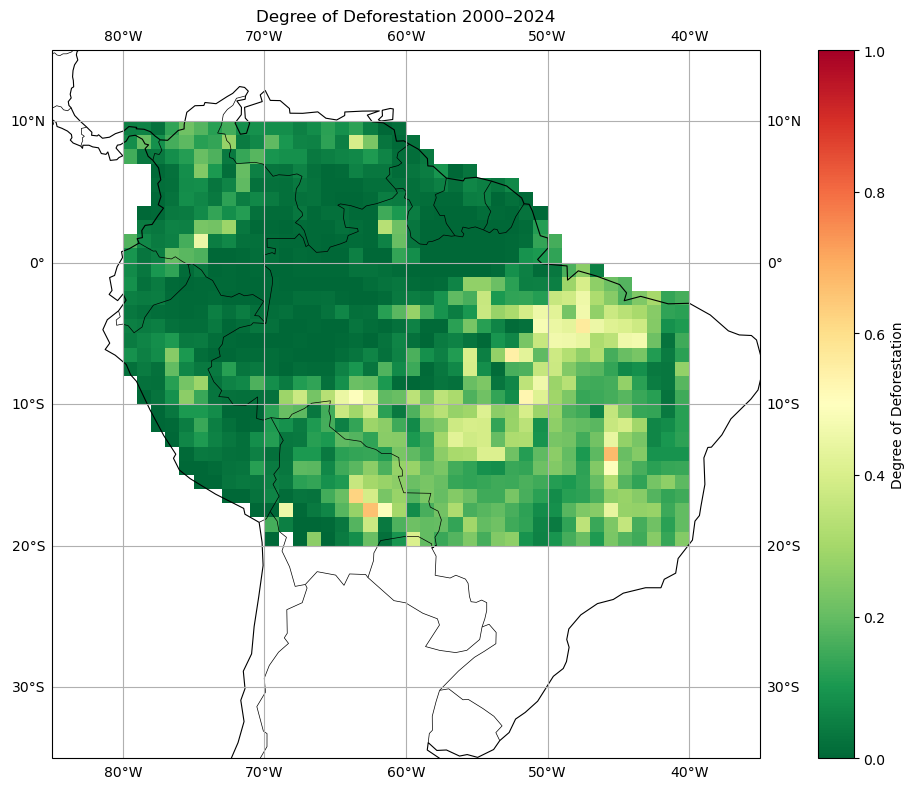

In [131]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

DoD.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdYlGn_r',
    vmin=0, vmax=1,
    cbar_kwargs={'label': 'Degree of Deforestation'}
)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

gl = ax.gridlines(draw_labels=True)
gl.xlocator = mticker.FixedLocator(range(-90, -39, 10))
gl.ylocator = mticker.FixedLocator(range(-30, 11, 10))

ax.set_title('Degree of Deforestation 2000–2024')
plt.tight_layout()
plt.savefig('/home/oscholz/plots/forest/DoD.png')
plt.show()

In [145]:
maxdef=int(Fo_diff.max())
maxdef

7966862

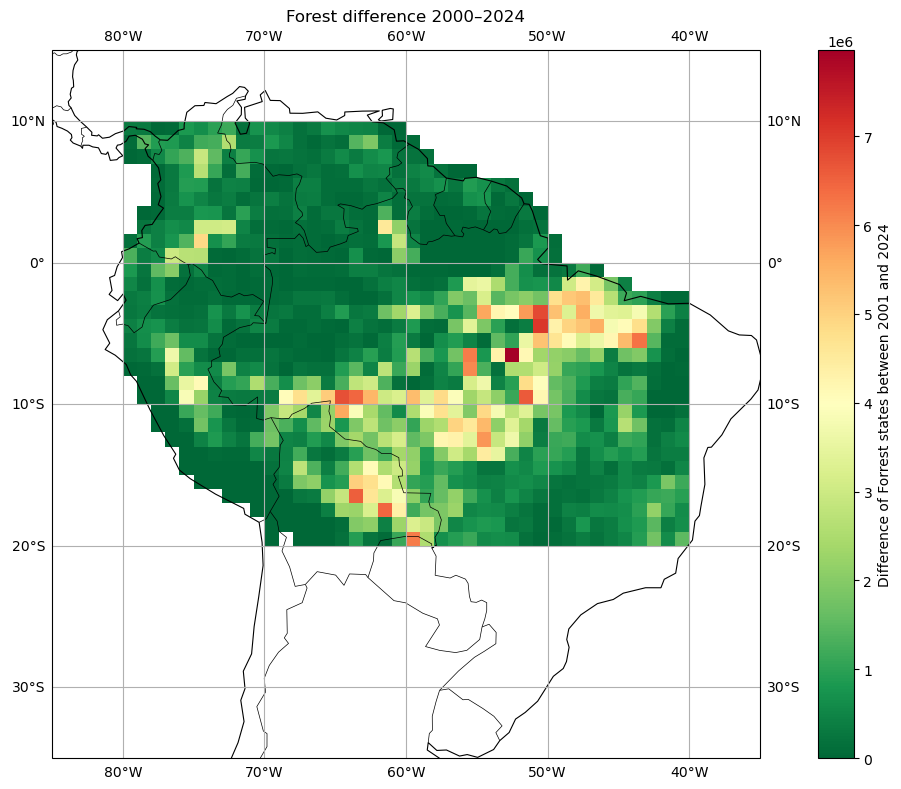

In [146]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

Fo_diff.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap='RdYlGn_r',
    vmin=0, vmax=maxdef,
    cbar_kwargs={'label': 'Difference of Forrest states between 2001 and 2024'}
)

ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

gl = ax.gridlines(draw_labels=True)
gl.xlocator = mticker.FixedLocator(range(-90, -39, 10))
gl.ylocator = mticker.FixedLocator(range(-30, 11, 10))

ax.set_title('Forest difference 2000–2024')
plt.tight_layout()
plt.savefig('/home/oscholz/plots/forest/difference.png')
plt.show()

# Modis Datensatz

In [196]:
dataset='CMF_low.nc' 

#choose between: 
# 'COT_liq.nc' or    (Cloud Optical Thickness of liqiud clouds)
# 'CMF_low.nc' or    (Cloud Mask Fraction of low clouds) 
# 'CPS_liq.nc'       (Cloud Particle Size of liquid cloud)
#or create a new file with concat.ipynb and choose that one

modis=xr.open_dataset('/projekt1/ag_maahn/data_obs_nobackup/modis/MCD06COSP_D3/merged/'+dataset)

if dataset=='COT_liq.nc':
    folder='cot_liq'
    header='Cloud Optical Thickness of liquid clouds' 
elif dataset=='CMF_low.nc':
    folder='cmf_low'
    header='Cloud Mask fraction of low clouds'
elif dataset=='CPS_liq.nc':
    folder='cps_liq'
    header='Cloud Particle Size of liquid clouds'
    

In [197]:
print(folder)
print(header)

cmf_low
Cloud Mask fraction of low clouds


In [198]:
modis

<xarray.Dataset> Size: 414MB
Dimensions:             (time: 8621, longitude: 40, latitude: 30)
Coordinates:
  * time                (time) datetime64[ns] 69kB 2002-07-04 ... 2026-03-11
  * longitude           (longitude) float64 320B -79.5 -78.5 ... -41.5 -40.5
  * latitude            (latitude) float64 240B -19.5 -18.5 -17.5 ... 8.5 9.5
Data variables:
    Mean                (time, longitude, latitude) float64 83MB ...
    Standard_Deviation  (time, longitude, latitude) float64 83MB ...
    Sum                 (time, longitude, latitude) float64 83MB ...
    Pixel_Counts        (time, longitude, latitude) float64 83MB ...
    Sum_Squares         (time, longitude, latitude) float64 83MB ...
Attributes:
    long_name:     Cloud Fraction from Cloud Mask (Low Clouds, CTP GE 680 hPa...
    units:         none
    _FillValue:    -999.0
    valid_min:     0.0
    valid_max:     1.0
    scale_factor:  1.0
    add_offset:    0.0

In [199]:
time_num = (modis.time - modis.time[0]).dt.days.values

def linear_trend_with_pvalue(y):
    mask = ~np.isnan(y)
    if mask.sum() < 2:
        return np.nan, np.nan
    slope, _, _, pvalue, _ = stats.linregress(time_num[mask], y[mask])
    return slope, pvalue

# Slope und p-Wert berechnen
slope, pvalue = xr.apply_ufunc(
    linear_trend_with_pvalue,
    modis["Mean"],
    input_core_dims=[["time"]],
    output_core_dims=[[], []],
    vectorize=True,
    output_dtypes=[float, float]
)

trend_modis = xr.Dataset({
    "trend_Mean": slope.transpose("latitude", "longitude"),
    "pvalue":     pvalue.transpose("latitude", "longitude")
})

In [200]:
trend_modis['trend_Mean']=trend_modis['trend_Mean']*365*10
trend_modis

<xarray.Dataset> Size: 20kB
Dimensions:     (latitude: 30, longitude: 40)
Coordinates:
  * latitude    (latitude) float64 240B -19.5 -18.5 -17.5 -16.5 ... 7.5 8.5 9.5
  * longitude   (longitude) float64 320B -79.5 -78.5 -77.5 ... -42.5 -41.5 -40.5
Data variables:
    trend_Mean  (latitude, longitude) float64 10kB -0.002897 ... 0.02626
    pvalue      (latitude, longitude) float64 10kB 0.5253 0.539 ... 4.047e-08

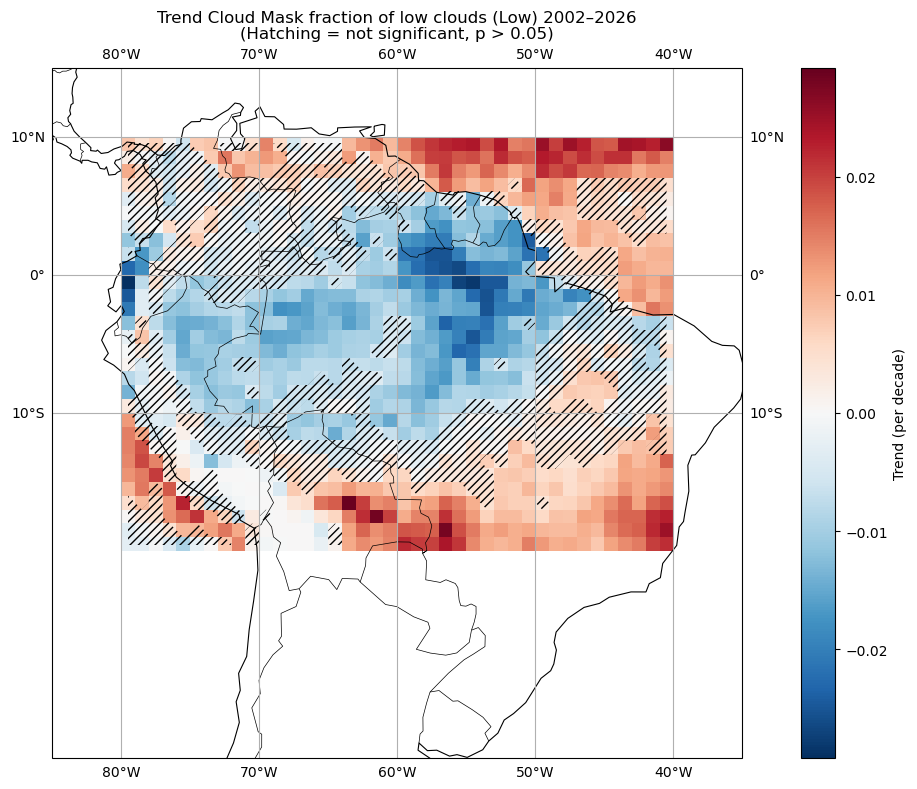

In [201]:
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={"projection": ccrs.PlateCarree()})

(trend_modis["trend_Mean"]).plot.pcolormesh(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r",
    cbar_kwargs={"label": "Trend (per decade)"}
)

# Non-significant areas hatched (p > 0.05)
sig_mask = trend_modis["pvalue"] > 0.05
ax.contourf(
    trend_modis.longitude, trend_modis.latitude,
    sig_mask.values,
    levels=[0.5, 1.5],
    hatches=["////"],
    colors="none",
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

gl = ax.gridlines(draw_labels=True)
gl.xlocator = mticker.FixedLocator(range(-90, -39, 10))
gl.ylocator = mticker.FixedLocator(range(-10, 11, 10))

ax.set_title(f"Trend {header} (Low) 2002–2026\n(Hatching = not significant, p > 0.05)")
plt.savefig(f'/home/oscholz/plots/{folder}/Trend_{folder}.png')
plt.tight_layout()
plt.show()

/tmp/ipykernel_318577/670533402.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


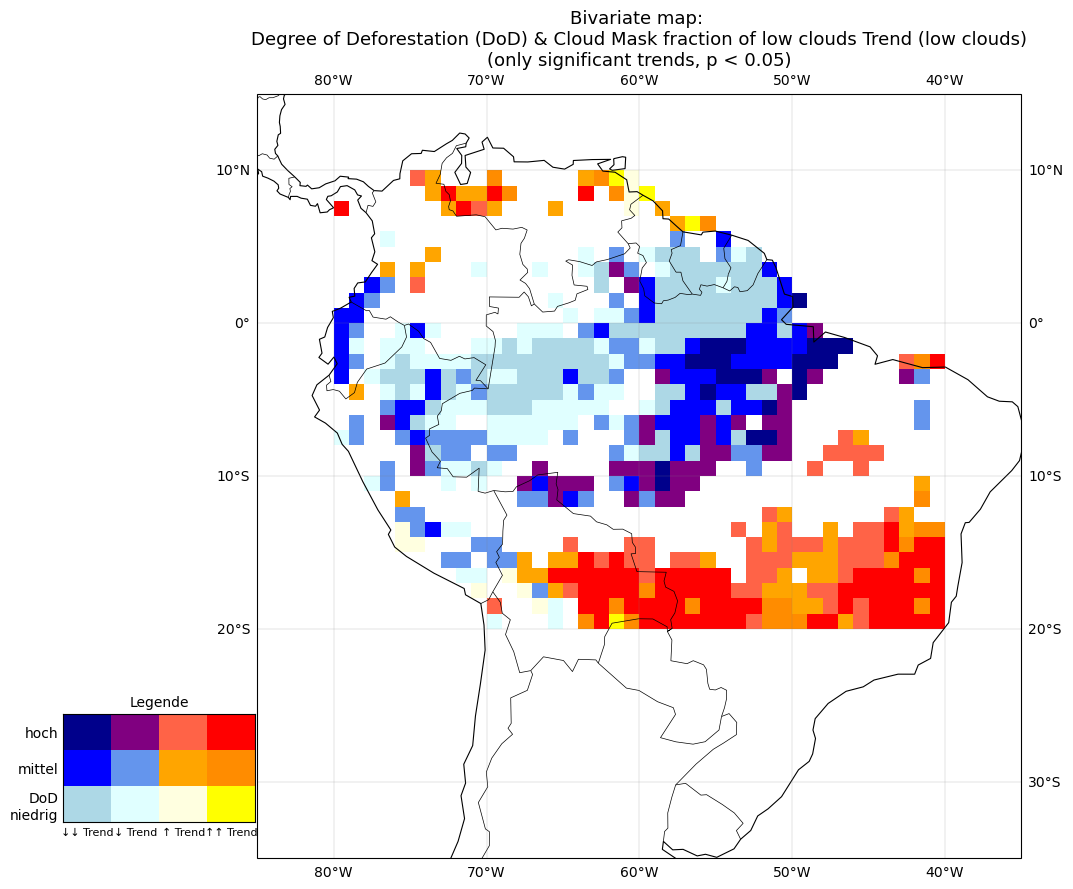

/tmp/ipykernel_318577/670533402.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


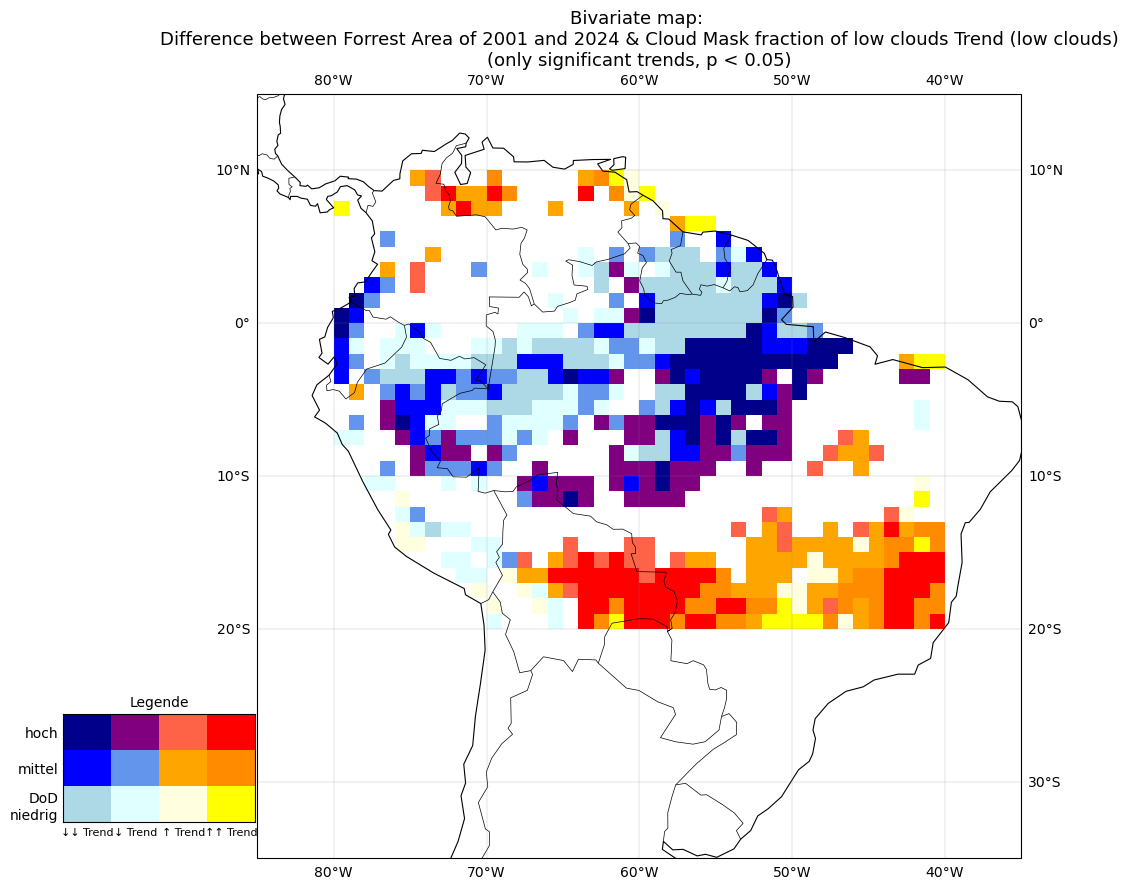

In [202]:
# ── 1. Interpolate Modis Data to Hansen-Grid ──────────────────────────────────
trend_sig = trend_modis["trend_Mean"].where(trend_modis["pvalue"] < 0.05)

x_mids = np.array([iv.mid for iv in ds_dod.x_bins.values])
y_mids = np.array([iv.mid for iv in ds_dod.y_bins.values])

trend_interp = trend_sig.interp(
    latitude=y_mids,
    longitude=x_mids,
    method="nearest"
)

# ── 2. extract values──────────────────────────────────────────────────────
dod_vals   = ds_dod["DoD"].squeeze().values            # (30, 40)
fodif_vals = ds_Fo_diff["Difference"].squeeze().values # (30, 40)
trend_vals = trend_interp.values                       # (30, 40)

# ── 3. classification ─────────────────────────────────────────────────────────
both_valid = ~np.isnan(dod_vals) & ~np.isnan(trend_vals)
dod_t = np.nanpercentile(dod_vals[both_valid], [33, 66])

both_valid_fo = ~np.isnan(fodif_vals) & ~np.isnan(trend_vals)
fodif_t = np.nanpercentile(fodif_vals[both_valid], [33, 66])

# Trend: 4 classes with 0 as natürlicher threshold
neg_vals = trend_vals[both_valid & (trend_vals < 0)]
pos_vals = trend_vals[both_valid & (trend_vals > 0)]
trend_t = [np.median(neg_vals), 0, np.median(pos_vals)]
# → 0: stark neg | 1: schwach neg | 2: schwach pos | 3: stark pos

def classify_dod(arr, thresholds):
    out = np.full(arr.shape, np.nan)
    out[arr <= thresholds[0]] = 0
    out[(arr > thresholds[0]) & (arr <= thresholds[1])] = 1
    out[arr > thresholds[1]] = 2
    return out
    
def classify_trend(arr, thresholds):
    out = np.full(arr.shape, np.nan)
    out[arr <= thresholds[0]] = 0
    out[(arr > thresholds[0]) & (arr <= thresholds[1])] = 1
    out[(arr > thresholds[1]) & (arr <= thresholds[2])] = 2
    out[arr > thresholds[2]] = 3
    return out

dod_class   = classify_dod(dod_vals,   dod_t)
trend_class = classify_trend(trend_vals, trend_t)
dof_class = classify_dod(fodif_vals, fodif_t)

# combined Index 0–11 (3 DoD × 4 Trend)
combo = np.full(dod_vals.shape, np.nan)
combo[both_valid] = dod_class[both_valid] * 4 + trend_class[both_valid]

combo_fo = np.full(fodif_vals.shape, np.nan)
combo_fo[both_valid_fo] = dof_class[both_valid_fo] * 4 + trend_class[both_valid_fo]

# ── 4. Bivariate colour matrix (3×4) ───────────────────────────────────────────
# Zeilen = DoD (0=niedrig → 2=hoch), Spalten = Trend (0=stark neg → 3=stark pos)
bivar_colors = [
    "lightblue",   # DoD low,  Trend stark neg
    "lightcyan",   # DoD low,  Trend schwach neg
    "lightyellow", # DoD low,  Trend schwach pos
    "yellow",      # DoD low,  Trend stark pos
    "blue",        # DoD mid,  Trend stark neg
    "cornflowerblue", # DoD mid, Trend schwach neg
    "orange",      # DoD mid,  Trend schwach pos
    "darkorange",  # DoD mid,  Trend stark pos
    "darkblue",    # DoD high, Trend stark neg
    "purple",      # DoD high, Trend schwach neg
    "tomato",      # DoD high, Trend schwach pos
    "red",         # DoD high, Trend stark pos
]
cmap_bivar = ListedColormap(bivar_colors)

# ── 5. plot map ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(
    figsize=(12, 9),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5)

im = ax.pcolormesh(
    x_mids, y_mids, combo,
    cmap=cmap_bivar, vmin=0, vmax=11,
    transform=ccrs.PlateCarree(), zorder=1
)

# Mask for NaN (not significant or no forrest)
nan_mask = np.where(np.isnan(combo), 0.4, np.nan)
ax.pcolormesh(
    x_mids, y_mids, nan_mask,
    cmap=ListedColormap(["white"]), vmin=0, vmax=1,
    transform=ccrs.PlateCarree(), zorder=1
)

ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
ax.set_title("Bivariate map: \n"
             f"Degree of Deforestation (DoD) & {header} Trend (low clouds)\n"
             "(only significant trends, p < 0.05)", fontsize=13)

# ── 6. Bivariate legend  ──────────────────────────────────────
legend_ax = fig.add_axes([0.02, 0.08, 0.16, 0.12])
legend_grid = np.arange(12).reshape(3, 4)
legend_ax.imshow(legend_grid, cmap=cmap_bivar, vmin=0, vmax=11,
                 origin="lower", aspect="auto")
legend_ax.set_xticks([0, 1, 2, 3])
legend_ax.set_xticklabels(["↓↓ Trend", "↓ Trend", "↑ Trend", "↑↑ Trend"], fontsize=8)
legend_ax.set_yticks([0, 1, 2])
legend_ax.set_yticklabels(["DoD\nniedrig", "mittel", "hoch"], fontsize=10)
legend_ax.set_title("Legende", fontsize=10)
legend_ax.tick_params(length=0)

plt.tight_layout()
plt.savefig(f'/home/oscholz/plots/{folder}/bivariate_map_DoD_{folder}.png')
plt.show()


#plot map with forrest difference ---------------------------------------------------------------------------------------------------------- 

fig, ax = plt.subplots(
    figsize=(12, 9),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5)

im = ax.pcolormesh(
    x_mids, y_mids, combo_fo,
    cmap=cmap_bivar, vmin=0, vmax=11,
    transform=ccrs.PlateCarree(), zorder=1
)

# Mask for NaN (not significant or no forrest)
nan_mask = np.where(np.isnan(combo), 0.4, np.nan)
ax.pcolormesh(
    x_mids, y_mids, nan_mask,
    cmap=ListedColormap(["white"]), vmin=0, vmax=1,
    transform=ccrs.PlateCarree(), zorder=1
)

ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
ax.set_title("Bivariate map: \n"
             f"Difference between Forrest Area of 2001 and 2024 & {header} Trend (low clouds)\n"
             "(only significant trends, p < 0.05)", fontsize=13)

# ── 6. Bivariate legend  ──────────────────────────────────────
legend_ax = fig.add_axes([0.02, 0.08, 0.16, 0.12])
legend_grid = np.arange(12).reshape(3, 4)
legend_ax.imshow(legend_grid, cmap=cmap_bivar, vmin=0, vmax=11,
                 origin="lower", aspect="auto")
legend_ax.set_xticks([0, 1, 2, 3])
legend_ax.set_xticklabels(["↓↓ Trend", "↓ Trend", "↑ Trend", "↑↑ Trend"], fontsize=8)
legend_ax.set_yticks([0, 1, 2])
legend_ax.set_yticklabels(["DoD\nniedrig", "mittel", "hoch"], fontsize=10)
legend_ax.set_title("Legende", fontsize=10)
legend_ax.tick_params(length=0)

plt.tight_layout()
plt.savefig(f'/home/oscholz/plots/{folder}/bivariate_map_area_{folder}.png')
plt.show()

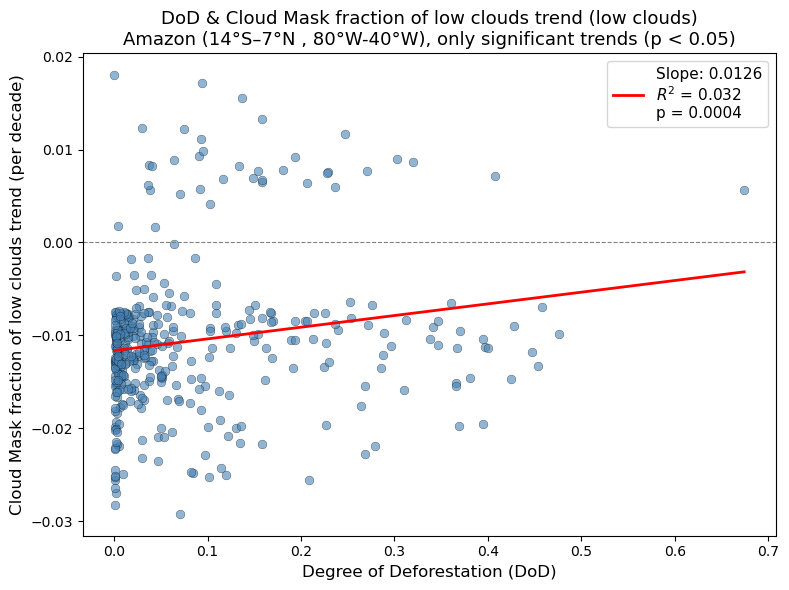

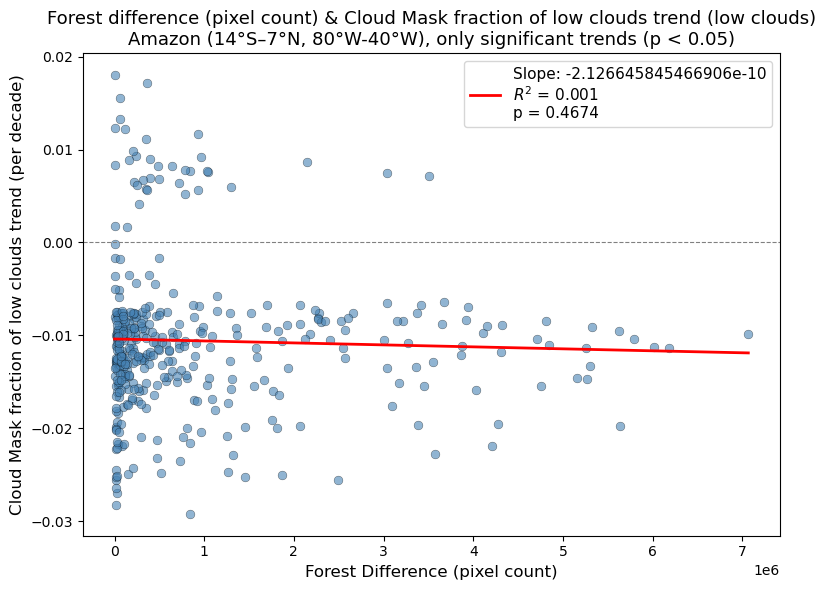

In [203]:
# ── Auf Amazonas-Kernbereich einschränken (14°S bis 7°N) ─────────────────────
lat_mask       = (y_mids >= -14) & (y_mids <= 7)
dod_vals_amz   = dod_vals[lat_mask, :]
trend_vals_amz = trend_vals[lat_mask, :]
dof_vals_amz   = fodif_vals[lat_mask, :]

both_valid_amz  = ~np.isnan(dod_vals_amz) & ~np.isnan(trend_vals_amz)
both_valid_amz2 = ~np.isnan(dof_vals_amz) & ~np.isnan(trend_vals_amz)

# ── Daten vorbereiten ─────────────────────────────────────────────────────────
dod_flat    = dod_vals_amz[both_valid_amz].flatten()
trend_flat  = trend_vals_amz[both_valid_amz].flatten()
dof_flat    = dof_vals_amz[both_valid_amz2].flatten()
trend_flat2 = trend_vals_amz[both_valid_amz2].flatten()

# ── Lineare Regression ────────────────────────────────────────────────────────
slope,  intercept,  r_value,  p_value,  std_err  = stats.linregress(dod_flat, trend_flat)
slope2, intercept2, r_value2, p_value2, std_err2 = stats.linregress(dof_flat, trend_flat2)

# ── Plot 1: DoD × Trend ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dod_flat, trend_flat, alpha=0.6, edgecolors="k", linewidths=0.3, s=40, color="steelblue")
x_line = np.linspace(dod_flat.min(), dod_flat.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, color="red", linewidth=2,
        label=f"Slope: {slope:.4f}\n$R^2$ = {r_value**2:.3f}\np = {p_value:.4f}")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Degree of Deforestation (DoD)", fontsize=12)
ax.set_ylabel(f"{header} trend (per decade)", fontsize=12)
ax.set_title(f"DoD & {header} trend (low clouds)\n"
             "Amazon (14°S–7°N , 80°W-40°W), only significant trends (p < 0.05)", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'/home/oscholz/plots/{folder}/scatter_DoD_{folder}.png', dpi=150, bbox_inches="tight")
plt.show()

# ── Plot 2: Fo_diff × Trend ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dof_flat, trend_flat2, alpha=0.6, edgecolors="k", linewidths=0.3, s=40, color="steelblue")
x_line2 = np.linspace(dof_flat.min(), dof_flat.max(), 100)
y_line2 = slope2 * x_line2 + intercept2
ax.plot(x_line2, y_line2, color="red", linewidth=2,
        label=f"Slope: {slope2:}\n$R^2$ = {r_value2**2:.3f}\np = {p_value2:.4f}")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Forest Difference (pixel count)", fontsize=12)
ax.set_ylabel(f"{header} trend (per decade)", fontsize=12)
ax.set_title(f"Forest difference (pixel count) & {header} trend (low clouds)\n"
             "Amazon (14°S–7°N, 80°W-40°W), only significant trends (p < 0.05)", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'/home/oscholz/plots/{folder}/scatter_pixel_{folder}.png', dpi=150, bbox_inches="tight")
plt.show()

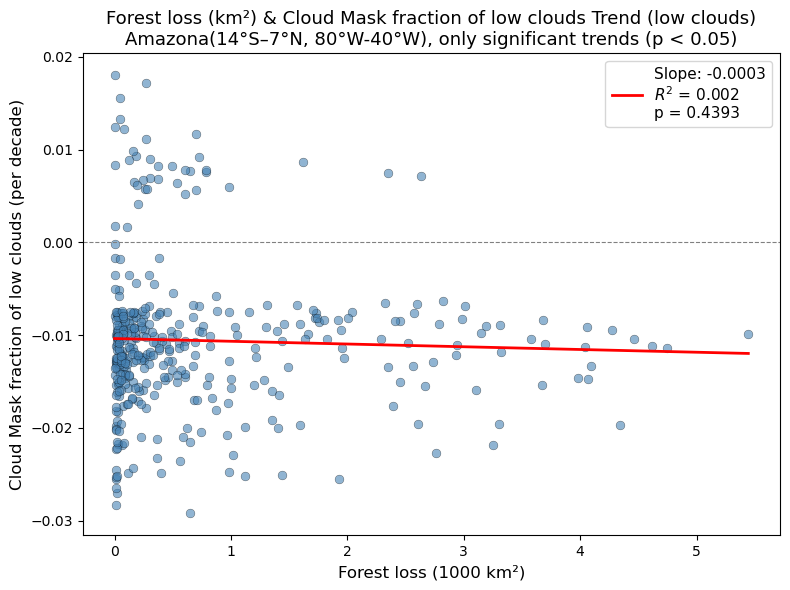

In [204]:
# ── Pixelfläche in km² pro 1°×1°-Box ─────────────────────────────────────────
R = 6371.0  # Erdradius in km
delta_lambda = np.deg2rad(1.0)  # 1° in Längenrichtung

# y_mids sind Mittelpunkte der Boxen → Grenzen bei ±0.5°
phi1 = np.deg2rad(y_mids - 0.5)
phi2 = np.deg2rad(y_mids + 0.5)
box_area_km2 = R**2 * delta_lambda * np.abs(np.sin(phi2) - np.sin(phi1))  # (n_lat,)

# Auf alle Längengrade ausdehnen: (n_lat,) → (n_lat, n_lon)
box_area_km2_2d = np.tile(box_area_km2[:, np.newaxis], (1, len(x_mids)))

# Pixelfläche in km²
pixels_per_box = 4000 * 4000
pixel_area_km2 = box_area_km2_2d / pixels_per_box  # (n_lat, n_lon)

# Amazonas-Maske anwenden
pixel_area_amz = pixel_area_km2[lat_mask, :]

# Fo_diff in km² umrechnen
dof_km2_vals_amz = dof_vals_amz * pixel_area_amz  # elementweise

# ── Daten für Regression ──────────────────────────────────────────────────────
dof_km2_flat  = dof_km2_vals_amz[both_valid_amz2].flatten()
# trend_flat2 bleibt gleich (gleiche Maske)

slope3, intercept3, r_value3, p_value3, std_err3 = stats.linregress(
    dof_km2_flat / 1000, trend_flat2  # pro 1000 km² für lesbare Slope-Werte
)

# ── Plot 3: Fo_diff in km² × Trend ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dof_km2_flat / 1000, trend_flat2, alpha=0.6, edgecolors="k",
           linewidths=0.3, s=40, color="steelblue")
x_line3 = np.linspace((dof_km2_flat / 1000).min(), (dof_km2_flat / 1000).max(), 100)
y_line3 = slope3 * x_line3 + intercept3
ax.plot(x_line3, y_line3, color="red", linewidth=2,
        label=f"Slope: {slope3:.4f}\n$R^2$ = {r_value3**2:.3f}\np = {p_value3:.4f}")
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_xlabel("Forest loss (1000 km²)", fontsize=12)
ax.set_ylabel(f"{header} (per decade)", fontsize=12)
ax.set_title(f"Forest loss (km²) & {header} Trend (low clouds)\n"
             "Amazona(14°S–7°N, 80°W-40°W), only significant trends (p < 0.05)", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'/home/oscholz/plots/{folder}/scatter_area_{folder}.png', dpi=150, bbox_inches="tight")
plt.show()

In [205]:
mei = pd.read_csv(
    "meiv2.data",
    sep=r'\s+',
    header=0,
    skipfooter=4,     # letzte 4 Zeilen ignorieren
    engine='python',  # nötig für skipfooter
    na_values=[-999, -999.0]  # fehlende Werte gleich sauber markieren
)

Gemeinsamer Zeitraum: 2002-07-01 00:00:00 – 2026-03-01 00:00:00, n=285

Normale Korrelation (lag=0): r=0.388, p=0.0000
Bester Lag: 0 Monate, r=0.388, p=0.0000


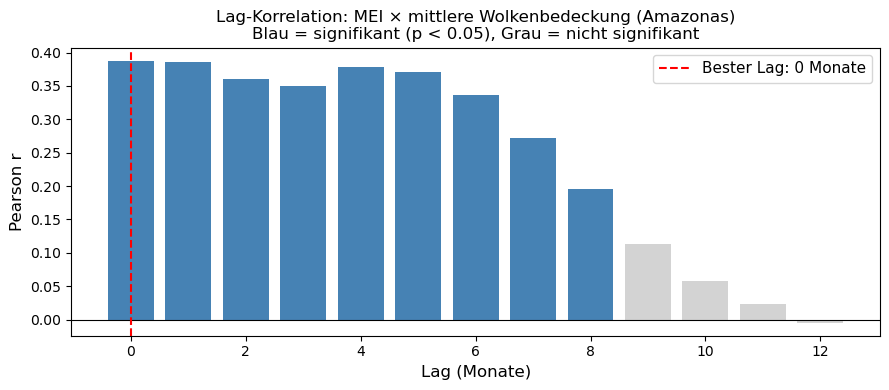

/tmp/ipykernel_318577/3916582423.py:101: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r_map[i, j], p_map[i, j] = stats.pearsonr(mei_lagged_best[valid], ts[valid])


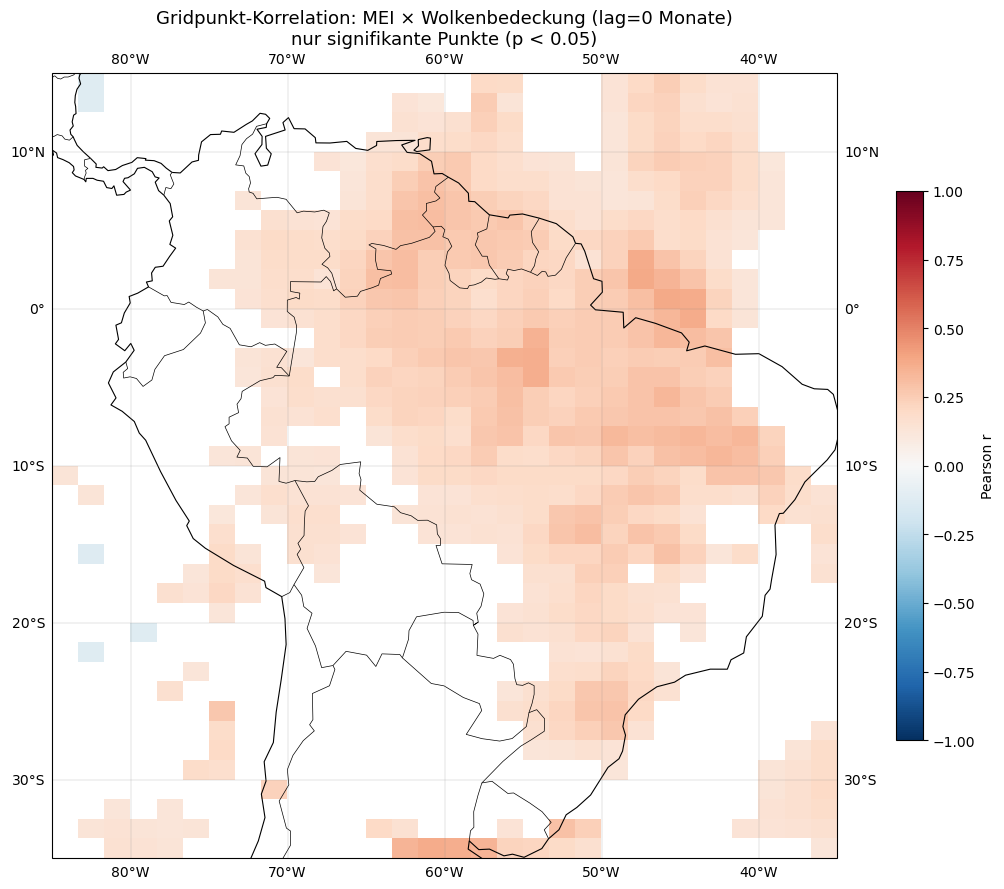

In [206]:
# ── 1. MODIS: Tagessdaten → Monatsmittel ─────────────────────────────────────
ds_monthly = modis.resample(time="MS").mean()  # MS = Monatsanfang
# ds_monthly: (time, latitude, longitude)

# ── 2. MEI: Wide → Long umformen ──────────────────────────────────────────────
# Spaltennamen = Saisons (DJ, JF, ..., ND) → zweiter Monat der Saison als Datum
season_to_month = {
    "DJ": 1, "JF": 2, "FM": 3, "MA": 4, "AM": 5, "MJ": 6,
    "JJ": 7, "JA": 8, "AS": 9, "SO": 10, "ON": 11, "ND": 12
}

mei_long = mei.melt(id_vars="year", var_name="season", value_name="MEI")
mei_long["month"] = mei_long["season"].map(season_to_month)
mei_long["time"] = pd.to_datetime(
    {"year": mei_long["year"], "month": mei_long["month"], "day": 1}
)
mei_long = mei_long.dropna(subset=["MEI"]).sort_values("time").set_index("time")
mei_ts = mei_long["MEI"]  # pandas Series mit datetime-Index

# ── 3. Gemeinsamen Zeitraum finden und alignen ────────────────────────────────
modis_times = pd.DatetimeIndex(ds_monthly.time.values)
common_times = modis_times.intersection(mei_ts.index)

ds_common  = ds_monthly.sel(time=common_times)
mei_common = mei_ts.loc[common_times].values  # numpy array, gleiche Länge

print(f"Gemeinsamer Zeitraum: {common_times[0]} – {common_times[-1]}, n={len(common_times)}")

# ── 4. Räumlich gemittelte Gesamtkorrelation (normale + Lag) ──────────────────
# Amazonas-Bereich mitteln
modis_mean_ts = ds_common["Mean"].sel(
    latitude=slice(lat_min, lat_max),
    longitude=slice(lon_min, lon_max)
).mean(dim=["latitude", "longitude"]).values

# Normale Korrelation
r, p = stats.pearsonr(mei_common, modis_mean_ts)
print(f"\nNormale Korrelation (lag=0): r={r:.3f}, p={p:.4f}")

# Lag-Korrelation: MEI führt Wolken um 0–12 Monate
lags = np.arange(0, 13)
lag_corrs = []
lag_pvals  = []

for lag in lags:
    mei_lagged   = mei_common[:-lag] if lag > 0 else mei_common
    modis_lagged = modis_mean_ts[lag:] if lag > 0 else modis_mean_ts
    r_lag, p_lag = stats.pearsonr(mei_lagged, modis_lagged)
    lag_corrs.append(r_lag)
    lag_pvals.append(p_lag)

lag_corrs = np.array(lag_corrs)
lag_pvals  = np.array(lag_pvals)
best_lag   = lags[np.argmax(np.abs(lag_corrs))]
print(f"Bester Lag: {best_lag} Monate, r={lag_corrs[best_lag]:.3f}, p={lag_pvals[best_lag]:.4f}")

# Plotten
#fig, ax = plt.subplots(figsize=(14, 4))
#ax.plot(mei_long["date"], mei_long["mei"], linewidth=0.8)
#ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
#ax.fill_between(mei_long["date"], mei_long["mei"], 0,
#                where=mei_long["mei"] > 0, color="red", alpha=0.3, label="El Niño")
#ax.fill_between(mei_long["date"], mei_long["mei"], 0,
#                where=mei_long["mei"] < 0, color="blue", alpha=0.3, label="La Niña")
#ax.set_title("Multivariate ENSO Index v2 (MEI.v2)")
#ax.set_ylabel("MEI")
#ax.legend()
#plt.tight_layout()
#plt.savefig("mei_timeseries.png", dpi=150)
#plt.show()

# ── 5. Plot: Lag-Korrelation gesamt ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(lags, lag_corrs, color=["steelblue" if p < 0.05 else "lightgray" for p in lag_pvals])
ax.axhline(0, color="k", linewidth=0.8)
ax.axvline(best_lag, color="red", linewidth=1.5, linestyle="--", label=f"Bester Lag: {best_lag} Monate")
ax.set_xlabel("Lag (Monate)", fontsize=12)
ax.set_ylabel("Pearson r", fontsize=12)
ax.set_title("Lag-Korrelation: MEI × mittlere Wolkenbedeckung (Amazonas)\n"
             "Blau = signifikant (p < 0.05), Grau = nicht signifikant", fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig("lag_korrelation_gesamt.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 6. Gridpunkt-weise Korrelation mit bestem Lag ────────────────────────────
#n_lat = len(ds_common.latitude)
#n_lon = len(ds_common.longitude)
_, n_lat, n_lon = modis_lagged_best.shape
r_map = np.full((n_lat, n_lon), np.nan)
p_map = np.full((n_lat, n_lon), np.nan)

mei_lagged_best   = mei_common[:-best_lag] if best_lag > 0 else mei_common
modis_lagged_best = ds_common["Mean"].values[best_lag:, :, :]  # (time, lat, lon)

for i in range(n_lat):
    for j in range(n_lon):
        ts = modis_lagged_best[:, i, j]
        valid = ~np.isnan(ts)
        if valid.sum() > 30:  # mind. 30 Monate für sinnvolle Korrelation
            r_map[i, j], p_map[i, j] = stats.pearsonr(mei_lagged_best[valid], ts[valid])

# ── 7. Karte: Gridpunkt-weise Korrelation ────────────────────────────────────
# Nur signifikante Punkte zeigen
r_map_sig = np.where(p_map < 0.05, r_map, np.nan)

fig, ax = plt.subplots(figsize=(12, 9),
                       subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS,   linewidth=0.5)

im = ax.imshow(
    r_map_sig,
    extent=[lon_min, lon_max, lat_min, lat_max],
    origin="lower",
    cmap="RdBu_r",
    vmin=-1, vmax=1,
    transform=ccrs.PlateCarree()
)

plt.colorbar(im, ax=ax, label="Pearson r", shrink=0.7)
ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5)
ax.set_title(f"Gridpunkt-Korrelation: MEI × Wolkenbedeckung (lag={best_lag} Monate)\n"
             f"nur signifikante Punkte (p < 0.05)", fontsize=13)
plt.tight_layout()
plt.savefig("korrelation_karte_mei_wolken.png", dpi=150, bbox_inches="tight")
plt.show()

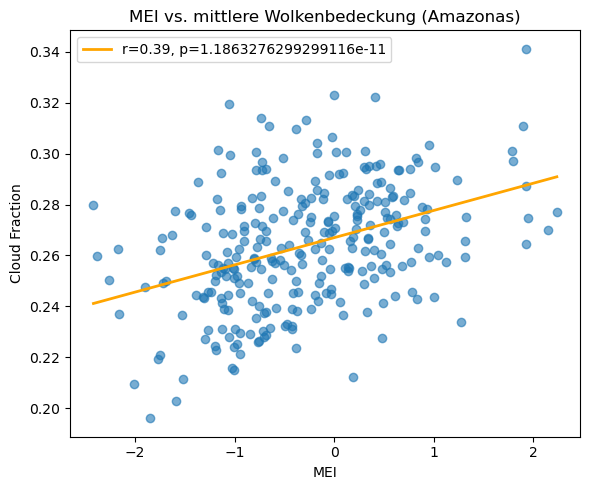

In [207]:
# NaNs entfernen (wichtig!)
valid = ~np.isnan(mei_common) & ~np.isnan(modis_mean_ts)
x = mei_common[valid]
y = modis_mean_ts[valid]

# Lineare Regression
slope, intercept, r, p, _ = stats.linregress(x, y)

# Scatter + Trendlinie
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x, y, alpha=0.6)

# Trendlinie
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept
ax.plot(x_fit, y_fit, linewidth=2, color='orange',
        label=f"r={r:.2f}, p={p:}")

ax.set_xlabel("MEI")
ax.set_ylabel("Cloud Fraction")
ax.set_title("MEI vs. mittlere Wolkenbedeckung (Amazonas)")
ax.legend()

plt.tight_layout()
plt.show()